In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import country_converter as coco
import plotly.express as px

In [93]:
df_global = pd.read_csv('dataset_global_fao.csv')
print(df_global.shape)
print(df_global.dtypes)
df_global.head()

(171, 9)
Zone                                    object
Code zone                                int64
Kcal_vegetaux                          float64
Kcal_animaux                           float64
Population_milliers                      int64
SousAlimentation_millions              float64
Disponibilite_calorique_totale_kcal    float64
Population_totale                        int64
Taux_sousnutrition_pct                 float64
dtype: object


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN


In [94]:
df_global.isna().sum()

Zone                                    0
Code zone                               0
Kcal_vegetaux                           0
Kcal_animaux                            0
Population_milliers                     0
SousAlimentation_millions              76
Disponibilite_calorique_totale_kcal     0
Population_totale                       0
Taux_sousnutrition_pct                 76
dtype: int64

In [95]:
pays_manquants_taux = df_global[df_global['Taux_sousnutrition_pct'].isna()]['Zone'].tolist()
print(f"nb pays manquants pour Taux_sousnutrition_pct: {len(pays_manquants_taux)}")
print(pays_manquants_taux)


nb pays manquants pour Taux_sousnutrition_pct: 76
['Allemagne', 'Antigua-et-Barbuda', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Barbade', 'Belgique', 'Belize', 'Bermudes', 'Bosnie-Herzégovine', 'Brunéi Darussalam', 'Brésil', 'Bélarus', 'Cabo Verde', 'Canada', 'Chypre', 'Croatie', 'Cuba', 'Danemark', 'Dominique', 'Espagne', 'Estonie', 'Fidji', 'Finlande', 'France', 'Fédération de Russie', 'Grenade', 'Grèce', 'Guyana', 'Hongrie', 'Irlande', 'Islande', 'Israël', 'Italie', 'Japon', 'Kazakhstan', 'Kiribati', 'Koweït', 'Lettonie', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Maldives', 'Malte', 'Maurice', 'Monténégro', 'Norvège', 'Nouvelle-Calédonie', 'Nouvelle-Zélande', 'Pays-Bas', 'Pologne', 'Polynésie française', 'Portugal', 'Roumanie', 'Royaume-Uni', 'République de Corée', 'République de Moldova', 'Saint-Kitts-et-Nevis', 'Saint-Vincent-et-les Grenadines', 'Sainte-Lucie', 'Samoa', 'Sao Tomé-et-Principe', 'Slovénie', 'Suisse', 'Suriname', 'Suède', 'Tadjikistan', 'Tchéquie (la)

In [96]:



df_valide = df_global.dropna(subset=['Taux_sousnutrition_pct']).copy()
df_valide['Part_animaux_pct'] = df_valide['Kcal_animaux'] / df_valide['Disponibilite_calorique_totale_kcal'] * 100

print(f"Échantillon : {len(df_valide)} pays\n")


corr1, p1 = stats.spearmanr(df_valide['Disponibilite_calorique_totale_kcal'], 
                              df_valide['Taux_sousnutrition_pct'])
print(f"① Disponibilité calorique vs Sous-nutrition")
print(f"   ρ = {corr1:.3f}, p-value = {p1:.6f}\n")


corr2, p2 = stats.spearmanr(df_valide['Part_animaux_pct'], 
                              df_valide['Taux_sousnutrition_pct'])
print(f"② Part animale vs Sous-nutrition")
print(f"   ρ = {corr2:.3f}, p-value = {p2:.6f}")

Échantillon : 95 pays

① Disponibilité calorique vs Sous-nutrition
   ρ = -0.893, p-value = 0.000000

② Part animale vs Sous-nutrition
   ρ = -0.527, p-value = 0.000000


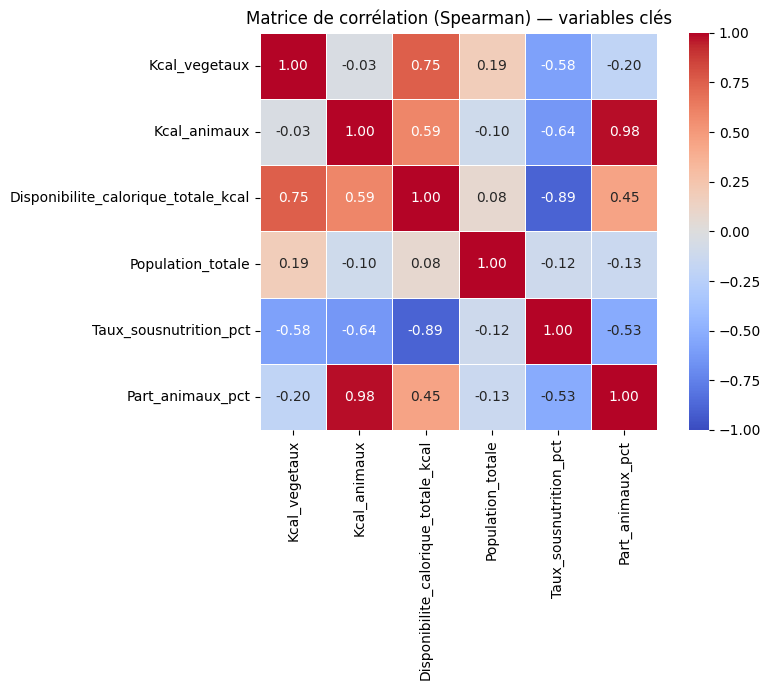

Échantillon utilisé : 95 pays (avec Taux_sousnutrition_pct exploitable)


In [97]:

df_valide = df_global.dropna(subset=['Taux_sousnutrition_pct']).copy()

df_valide['Part_animaux_pct'] = df_valide['Kcal_animaux'] / df_valide['Disponibilite_calorique_totale_kcal'] * 100

cols_analyse = ['Kcal_vegetaux', 'Kcal_animaux', 'Disponibilite_calorique_totale_kcal', 
                 'Population_totale', 'Taux_sousnutrition_pct', 'Part_animaux_pct']
corr_matrix = df_valide[cols_analyse].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matrice de corrélation (Spearman) — variables clés')
plt.tight_layout()
plt.show()

print(f"Échantillon utilisé : {len(df_valide)} pays (avec Taux_sousnutrition_pct exploitable)")

=== Statistiques descriptives ===
       Taux_sousnutrition_pct  Disponibilite_calorique_totale_kcal  \
count               95.000000                           171.000000   
mean                16.551833                          2843.649123   
std                 11.910288                           440.889895   
min                  3.359086                          1879.000000   
25%                  7.060328                          2518.500000   
50%                 12.372835                          2826.000000   
75%                 23.304327                          3184.000000   
max                 50.402249                          3770.000000   

       Population_totale  
count       1.710000e+02  
mean        4.092004e+07  
std         1.485241e+08  
min         5.400000e+04  
25%         2.543500e+06  
50%         9.413000e+06  
75%         2.888150e+07  
max         1.416667e+09  

=== Skewness (asymétrie) ===
Taux_sousnutrition_pct : 1.03
Disponibilite_calorique_totale_k

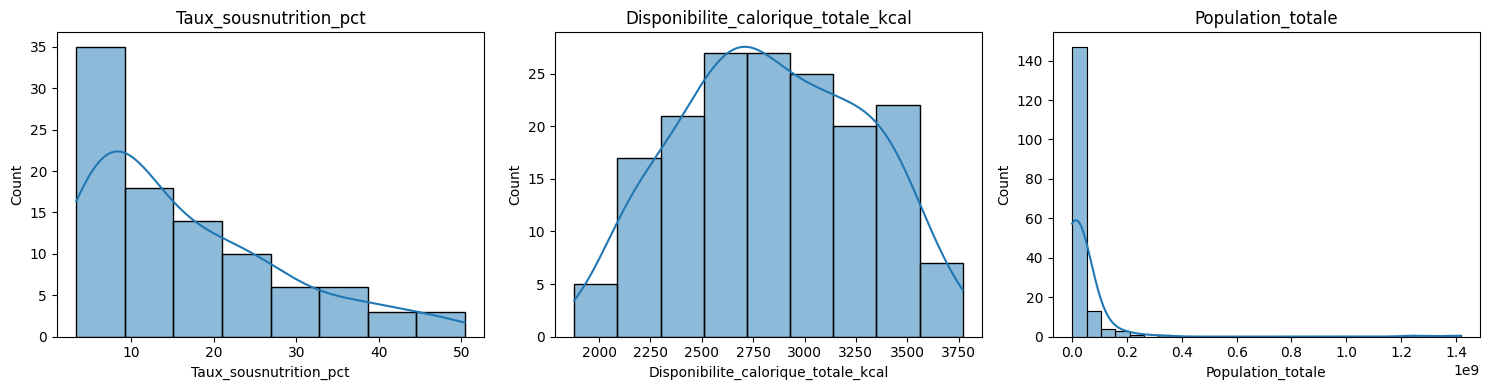

In [98]:

variables_cles = ['Taux_sousnutrition_pct', 'Disponibilite_calorique_totale_kcal', 'Population_totale']

print("=== Statistiques descriptives ===")
print(df_global[variables_cles].describe())

print("\n=== Skewness (asymétrie) ===")
for var in variables_cles:
    print(f"{var} : {skew(df_global[var].dropna()):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables_cles):
    sns.histplot(df_global[var], kde=True, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()

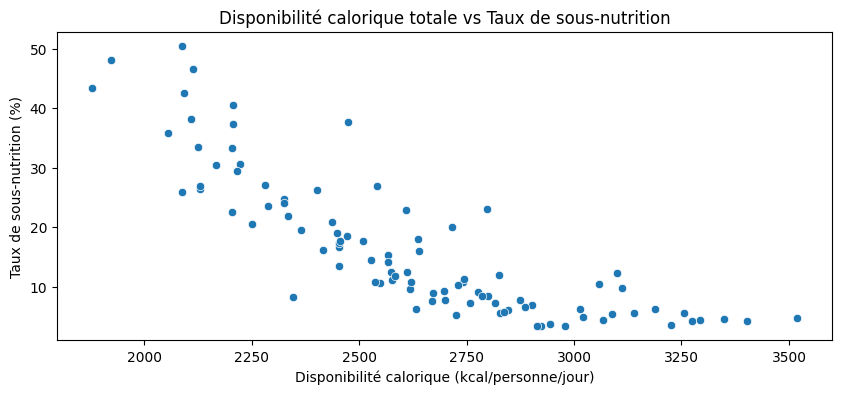

In [99]:
# ============ 2. Analyse bivariée ============
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_global, x='Disponibilite_calorique_totale_kcal', y='Taux_sousnutrition_pct')
plt.title('Disponibilité calorique totale vs Taux de sous-nutrition')
plt.xlabel('Disponibilité calorique (kcal/personne/jour)')
plt.ylabel('Taux de sous-nutrition (%)')
plt.show()

In [100]:
# ============ 3. Top/Bottom rankings ============
print("\n=== Top 10 - Taux de sous-nutrition le PLUS ÉLEVÉ ===")
print(df_global.nlargest(10, 'Taux_sousnutrition_pct')[['Zone', 'Taux_sousnutrition_pct']].to_string(index=False))

print("\n=== Top 10 - Taux de sous-nutrition le PLUS FAIBLE ===")
print(df_global.nsmallest(10, 'Taux_sousnutrition_pct')[['Zone', 'Taux_sousnutrition_pct']].to_string(index=False))

print("\n=== Top 10 - Disponibilité calorique la PLUS FAIBLE ===")
print(df_global.nsmallest(10, 'Disponibilite_calorique_totale_kcal')[['Zone', 'Disponibilite_calorique_totale_kcal']].to_string(index=False))



=== Top 10 - Taux de sous-nutrition le PLUS ÉLEVÉ ===
                                      Zone  Taux_sousnutrition_pct
                                     Haïti               50.402249
                                    Zambie               48.146365
                                  Zimbabwe               46.643110
                 République centrafricaine               43.327556
République populaire démocratique de Corée               42.578831
                                     Congo               40.467626
                                     Tchad               38.206628
                                    Angola               37.723547
                                   Libéria               37.261295
                                Madagascar               35.768811

=== Top 10 - Taux de sous-nutrition le PLUS FAIBLE ===
               Zone  Taux_sousnutrition_pct
            Arménie                3.359086
           Malaisie                3.365077
              Chili 

In [101]:
# ============ 4. Table pivot : groupes de sous-nutrition ============
df_global['Groupe_sousnutrition'] = pd.qcut(
    df_global['Taux_sousnutrition_pct'], q=3, labels=['Faible', 'Moyen', 'Élevé']
)

pivot_groupe = df_global.pivot_table(
    index='Groupe_sousnutrition',
    values=['Kcal_vegetaux', 'Kcal_animaux', 'Disponibilite_calorique_totale_kcal'],
    aggfunc='mean',
    observed=True
)
print("\n=== Pivot : moyenne calorique par groupe de sous-nutrition ===")
print(pivot_groupe)


=== Pivot : moyenne calorique par groupe de sous-nutrition ===
                      Disponibilite_calorique_totale_kcal  Kcal_animaux  \
Groupe_sousnutrition                                                      
Faible                                        2968.937500    526.718750   
Moyen                                         2636.451613    329.709677   
Élevé                                         2259.687500    208.218750   

                      Kcal_vegetaux  
Groupe_sousnutrition                 
Faible                  2442.218750  
Moyen                   2306.741935  
Élevé                   2051.468750  


In [102]:
pivot_groupe['Part_animaux_pct'] = (pivot_groupe['Kcal_animaux'] / pivot_groupe['Disponibilite_calorique_totale_kcal']) * 100
print("\n=== Part des calories animales par groupe ===")
print(pivot_groupe[['Part_animaux_pct']])


=== Part des calories animales par groupe ===
                      Part_animaux_pct
Groupe_sousnutrition                  
Faible                       17.740985
Moyen                        12.505812
Élevé                         9.214493


In [103]:


df_global['Continent'] = coco.convert(
    names=df_global['Code zone'].tolist(),
    src='FAOcode',
    to='continent',
    not_found='NON_TROUVE'
)

df_global.loc[df_global['Zone'] == 'Soudan', 'Continent'] = 'Africa'
non_trouves = df_global[df_global['Continent'] == 'NON_TROUVE']['Zone'].tolist()
print(f"non: {len(non_trouves)}")
print(non_trouves)

276 not found in FAOcode


non: 0
[]


In [104]:
print(df_global['Continent'].value_counts())

Continent
Africa     45
Asia       42
Europe     39
America    36
Oceania     9
Name: count, dtype: int64


In [105]:
df_global.sample(10)

,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Groupe_sousnutrition,Continent
51,Fédération de Russie,185,2517.0,843.0,142834,NaN,3360.0,142834000,NaN,NaN,Europe
111,Ouganda,226,1943.0,183.0,37579,12.6,2126.0,37579000,33.529365,Élevé,Africa
21,Botswana,20,1948.0,377.0,2021,0.5,2325.0,2021000,24.740228,Élevé,Africa
67,Iran (République islamique d'),102,2784.0,305.0,77447,4.2,3089.0,77447000,5.423064,Faible,Asia
146,Sénégal,195,2289.0,164.0,14133,1.9,2453.0,14133000,13.443713,Moyen,Africa
160,Venezuela (République bolivarienne du),236,2157.0,476.0,30405,1.9,2633.0,30405000,6.248972,Faible,America
110,Oman,221,2497.0,643.0,3632,0.2,3140.0,3632000,5.506608,Faible,Asia
136,Sao Tomé-et-Principe,193,2211.0,187.0,193,NaN,2398.0,193000,NaN,NaN,Africa
62,Haïti,93,1935.0,154.0,10317,5.2,2089.0,10317000,50.402249,Élevé,America
99,Monténégro,273,2368.0,1122.0,621,NaN,3490.0,621000,NaN,NaN,Europe


In [106]:
continent_stats = df_global.groupby('Continent').agg(
    Nb_pays=('Zone', 'count'),
    Nb_pays_avec_donnee=('Taux_sousnutrition_pct', 'count'),
    Taux_sousnutrition_moyen=('Taux_sousnutrition_pct', 'mean'),
    Taux_sousnutrition_median=('Taux_sousnutrition_pct', 'median'),
    Disponibilite_calorique_moyenne=('Disponibilite_calorique_totale_kcal', 'mean')
).sort_values('Taux_sousnutrition_moyen', ascending=False)

print(continent_stats)

           Nb_pays  Nb_pays_avec_donnee  Taux_sousnutrition_moyen  \
Continent                                                           
Africa          45                   42                 21.473585   
Asia            42                   31                 13.622042   
America         36                   18                 12.637913   
Europe          39                    4                  5.191961   
Oceania          9                    0                       NaN   

           Taux_sousnutrition_median  Disponibilite_calorique_moyenne  
Continent                                                              
Africa                     22.204349                      2530.511111  
Asia                       10.811827                      2798.142857  
America                    10.563914                      2782.916667  
Europe                      5.397468                      3290.641026  
Oceania                          NaN                      2927.666667  


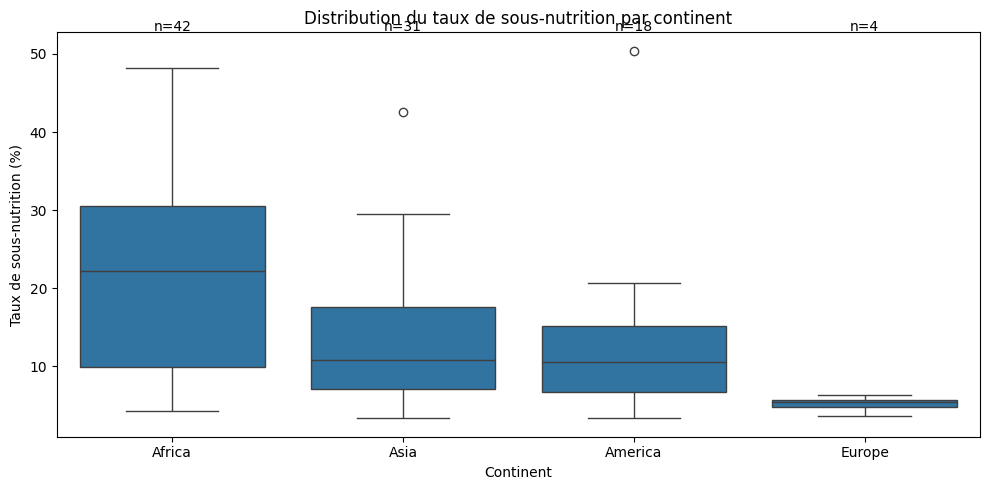

In [107]:
plt.figure(figsize=(10, 5))
df_plot = df_global.dropna(subset=['Taux_sousnutrition_pct'])
ordre = df_plot.groupby('Continent')['Taux_sousnutrition_pct'].median().sort_values(ascending=False).index

ax = sns.boxplot(data=df_plot, x='Continent', y='Taux_sousnutrition_pct', order=ordre)

for i, continent in enumerate(ordre):
    n = df_plot[df_plot['Continent'] == continent].shape[0]
    ax.text(i, df_plot['Taux_sousnutrition_pct'].max() * 1.05, f'n={n}', 
            ha='center', fontsize=10)

plt.title('Distribution du taux de sous-nutrition par continent')
plt.ylabel('Taux de sous-nutrition (%)')
plt.tight_layout()
plt.show()

In [109]:
df_global['ISO3'] = coco.convert(names=df_global['Code zone'].tolist(), src='FAOcode', to='ISO3', not_found=None)

manque_iso = df_global[df_global['ISO3'].isna()]['Zone'].tolist()
print(f"nb_pays_manquants: {len(manque_iso)}")
print(manque_iso)

276 not found in FAOcode


nb_pays_manquants: 0
[]


In [110]:
fig1 = px.choropleth(
    df_global,
    locations='ISO3',
    color='Taux_sousnutrition_pct',
    hover_name='Zone',
    color_continuous_scale='Reds',
    title='Taux de sous-nutrition par pays (%)',
    labels={'Taux_sousnutrition_pct': 'Taux (%)'}
)
fig1.update_layout(height=500)
fig1.show()

In [111]:
fig2 = px.choropleth(
    df_global,
    locations='ISO3',
    color='Disponibilite_calorique_totale_kcal',
    hover_name='Zone',
    color_continuous_scale='RdYlGn',  
    title='Disponibilité calorique totale par pays (kcal/personne/jour)',
    labels={'Disponibilite_calorique_totale_kcal': 'Kcal/jour'}
)
fig2.update_layout(height=500)
fig2.show()

## Régions les plus affectées par la sous-nutrition

### Constat principal — disparités entre continents

L'analyse porte sur les 171 pays du dataset, répartis en 5 continents.
Cependant, seuls **95 pays disposent d'une valeur exploitable** de
`Taux_sousnutrition_pct` (répartition inégale entre continents, cf. tableau
ci-dessous) — c'est donc sur ce sous-échantillon de 95 pays que reposent
les statistiques par continent présentées ici :

| Continent | Taux moyen | Taux médian | Disponibilité calorique moyenne | Couverture |
|---|---|---|---|---|
| **Afrique** | **21,5 %** | **22,2 %** | 2530 kcal | 42/45 pays (93 %) |
| Asie | 13,6 % | 10,8 % | 2798 kcal | 31/42 pays (74 %) |
| Amérique | 12,6 % | 10,6 % | 2783 kcal | 18/36 pays (50 %) |
| Europe | 5,2 % | 5,4 % | 3291 kcal | 4/39 pays (10 %) |
| Océanie | — | — | 2928 kcal | 0/9 pays (0 %) |

**L'Afrique est le continent le plus affecté**, avec un taux de
sous-nutrition moyen 4 fois supérieur à celui de l'Europe, et la
disponibilité calorique la plus faible des 5 continents — une relation
inverse cohérente avec la corrélation négative forte observée précédemment
(ρ = -0,888, cf. analyse de corrélation).

L'Afrique présente également la plus forte **hétérogénéité interne** (boîte
la plus étendue sur le boxplot ci-dessus, de ~10 % à ~30 %), révélant une
situation très contrastée entre pays africains plutôt qu'un phénomène
uniforme sur tout le continent.

### Classement — pays les plus et les moins affectés

**Top 10 des pays les plus touchés** (tous situés en Afrique subsaharienne
ou dans des contextes de fragilité politique) :
Haïti (50,4 %), Zambie (48,1 %), Zimbabwe (46,6 %), République
centrafricaine (43,3 %), Corée du Nord (42,6 %), Congo (40,5 %), Tchad
(38,2 %), Angola (37,7 %), Libéria (37,3 %), Madagascar (35,8 %).

**Top 10 des pays les moins touchés** (économies à revenu intermédiaire,
principalement en Amérique latine, Asie et